In [ ]:
import gdsfactory as gf
import kfactory as kf
from kfactory.utils.fill import fill_tiled
from helpers import wafer_spec 
from helpers.die_estimator import estimate_max_dies_on_wafer, plot_die_packing
from flexgrid import flexgrid

from litho_markers import mla150_overlay_marker, ebpg_pam_marker_array

from EKST_v2_BRT import ekst_v2_brt_master
from EKST_v2_STEPHAN import (
    stephan_serpentine_20h,
    stephan_inline_12h,
)

from ekin_master_die import (
    edge_coupler_array_stph_but,
    edge_coupler_array_stph_tap,
)

from ekin_master_die import edge_coupler_array_ekn_def_butt, edge_coupler_array_ekn_def_butt_3loops, edge_coupler_array_ekn_def_centerskip
from logo_maker import svg_logo
from wafer_component import wafer_from_spec


/home/sadilek/Dev/mesaplus/mesapdk-lab/.venv/lib/python3.13/site-packages/kfactory/decorators.py:406: UserWarning: `width` overrides `start_width`. Use only `start_width` going forward.
  cell = f(**params)  # type: ignore[call-arg]


In [2]:

VERBOSE = True
ADD_TILES = True
EXPORT_FILES = False

WAFER_ID = "STPH_v0_W00"


SIN_THICKNESS = 300
TEOS_THICKNESS = 3000
PECVD_OXIDE_THICKNESS = 5000
TIO2_THICKNESS = 0

STEPHAN_TAPEOUT_TABLE = (
    (3,  4.0,  "but", "S"),
    (4,  4.0,  "tap", "S"),
    (5,  6.0,  "but", "S"),
    (6,  6.0,  "tap", "S"),
    (7,  8.0,  "but", "S"),
    (8,  8.0,  "tap", "S"),
    (9,  10.0, "but", "S"),
    (10, 10.0, "tap", "S"),
    (11, 12.0, "but", "S"),
    (12, 12.0, "tap", "S"),

    (13, 4.0,  "but", "S"),
    (14, 4.0,  "tap", "S"),
    (15, 6.0,  "but", "S"),
    (16, 6.0,  "tap", "S"),
    (17, 8.0,  "but", "S"),
    (18, 8.0,  "tap", "S"),
    (19, 10.0, "but", "S"),
    (20, 10.0, "tap", "S"),
    (21, 12.0, "but", "S"),
    (22, 12.0, "tap", "S"),

    (23, 6.0,  "but", "I"),
    (24, 10.0, "but", "I"),
)

In [3]:

"""
Getting die dimensions for wafer utilization estimation.
and places for assignment of dies on wafer map.
"""
my_die = stephan_serpentine_20h()
wafer = wafer_spec.make_semi_wafer_spec("100mm", edge_exclusion_um=3000, use_secondary_flat=False)
result = estimate_max_dies_on_wafer(
    die=my_die,
    wafer=wafer,
    allow_rotation=True,
    offset_samples=11,
)

wafer_filled= wafer_from_spec(wafer=wafer)
wafer_filled.locked = False
assign_array = result.index_map.copy()


"""
Generating the logo that will be placed on the dies.
"""
logo = svg_logo(
        svg_path="./static/AQO_logo2.svg",
        layer=gf.get_layer('M1'),
        target_width_um=1500.0,   # final width in um
        resolution=0.08,         # smaller -> smoother curves
        center=True,
    )


FAN_IN_DEFS = {
    "but": edge_coupler_array_stph_but,
    "tap": edge_coupler_array_stph_tap,
}

SERPENTINE_DEFS = {
    "S": stephan_serpentine_20h,
    "I": stephan_inline_12h,
}

/home/sadilek/Dev/mesaplus/mesapdk-lab/EKST_v2_STEPHAN.py:889: UserWarning: No registered width taper for layer MH. Skipping.
  gnd_collector_ports = place_gnd_via_bank(
/home/sadilek/Dev/mesaplus/mesapdk-lab/EKST_v2_STEPHAN.py:897: UserWarning: No registered width taper for layer M1. Skipping.
  collector_ref = route_gnd_collector_to_pad(
/home/sadilek/Dev/mesaplus/mesapdk-lab/EKST_v2_STEPHAN.py:916: UserWarning: No registered width taper for layer M1. Skipping.
  route_heater_signals_to_south_pads(


In [4]:
STEPHAN_DIE_DEFS = {}

for die_nr, width, fan_in_name, structure_name in STEPHAN_TAPEOUT_TABLE:
    serpentine_def = SERPENTINE_DEFS[structure_name]
    fan_in_def = FAN_IN_DEFS[fan_in_name]

    STEPHAN_DIE_DEFS[die_nr] = gf.partial(
        serpentine_def,
        width=width,
        ec_array_def=fan_in_def,
        logo=logo,
        label=( "STPH_v0\n{:02d} {} {:.0f}um".format(die_nr, structure_name, width)
        ),
    )

STEPHAN_DIE_DEFS[1] = gf.partial(
    ekst_v2_brt_master,
    widths=(6.0,8.0,10.0,12.0),
    bend_rads= (300, 600, 900, 1200, 1500, 1800, 2100),
    ext_grp_spacing=127,
    ec_array_def=edge_coupler_array_ekn_def_butt,
    logo=logo, 
    logo_loc=(8500, -3650),
    label=(
        f"{WAFER_ID.split('_')[0]}_{WAFER_ID.split('_')[1]}\n"
        "01 BRT"
    ),
)

STEPHAN_DIE_DEFS[2] = gf.partial(
    ekst_v2_brt_master,
    widths=(6.0,8.0,10.0,12.0),
    bend_rads= (300, 600, 900, 1200, 1500, 1800, 2100),
    ext_grp_spacing=127,
    ec_array_def=edge_coupler_array_ekn_def_butt,
    logo=logo, 
    logo_loc=(8500, -3650),
    label=(
        f"{WAFER_ID.split('_')[0]}_{WAFER_ID.split('_')[1]}\n"
        "02 BRT"
    ),
)

/home/sadilek/Dev/mesaplus/mesapdk-lab/EKST_v2_STEPHAN.py:889: UserWarning: No registered width taper for layer MH. Skipping.
  gnd_collector_ports = place_gnd_via_bank(
/home/sadilek/Dev/mesaplus/mesapdk-lab/EKST_v2_STEPHAN.py:897: UserWarning: No registered width taper for layer M1. Skipping.
  collector_ref = route_gnd_collector_to_pad(
/home/sadilek/Dev/mesaplus/mesapdk-lab/EKST_v2_STEPHAN.py:916: UserWarning: No registered width taper for layer M1. Skipping.
  route_heater_signals_to_south_pads(
/home/sadilek/Dev/mesaplus/mesapdk-lab/.venv/lib/python3.13/site-packages/kfactory/decorators.py:406: UserWarning: `width` overrides `start_width`. Use only `start_width` going forward.
  cell = f(**params)  # type: ignore[call-arg]
/home/sadilek/Dev/mesaplus/mesapdk-lab/.venv/lib/python3.13/site-packages/gdsfactory/component.py:1386: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitl

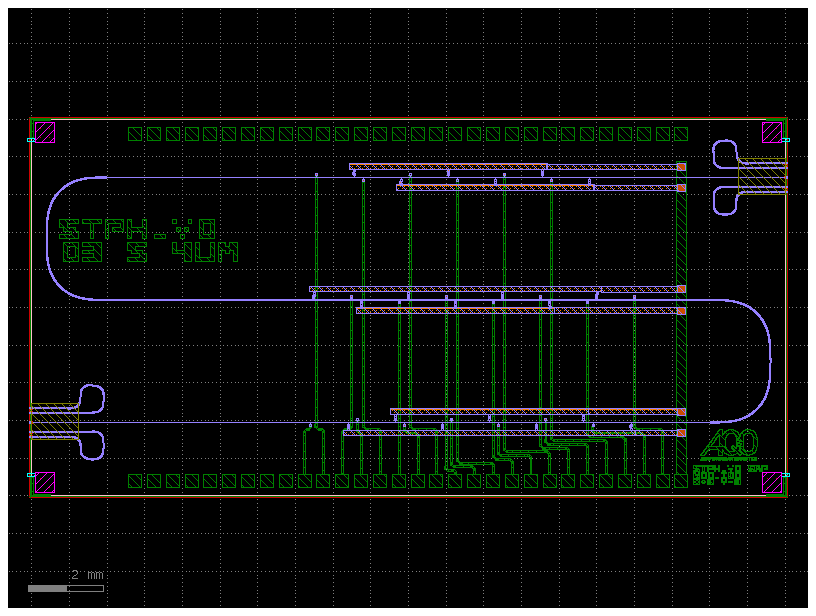

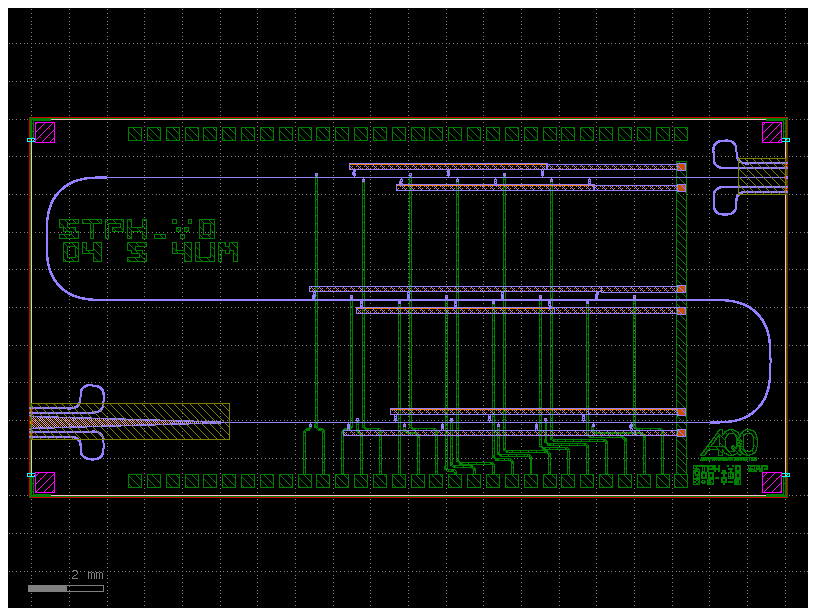

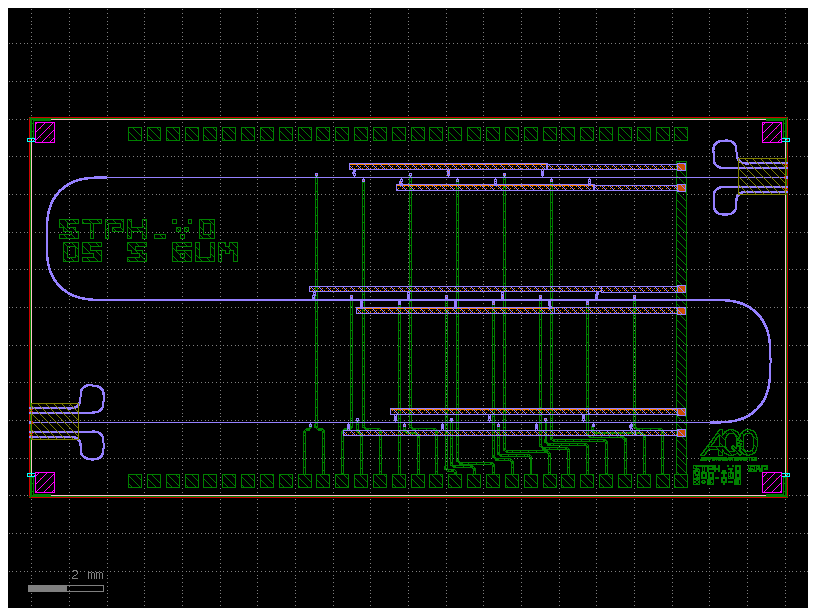

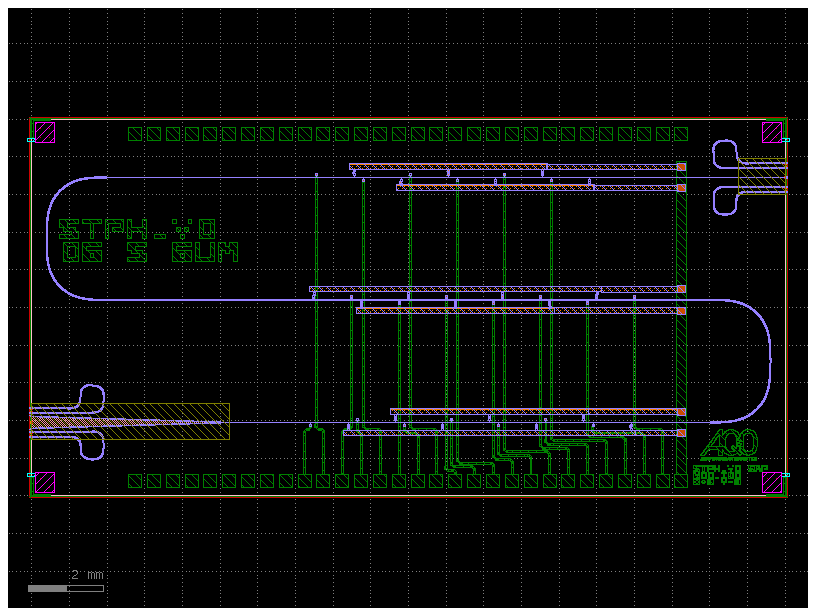

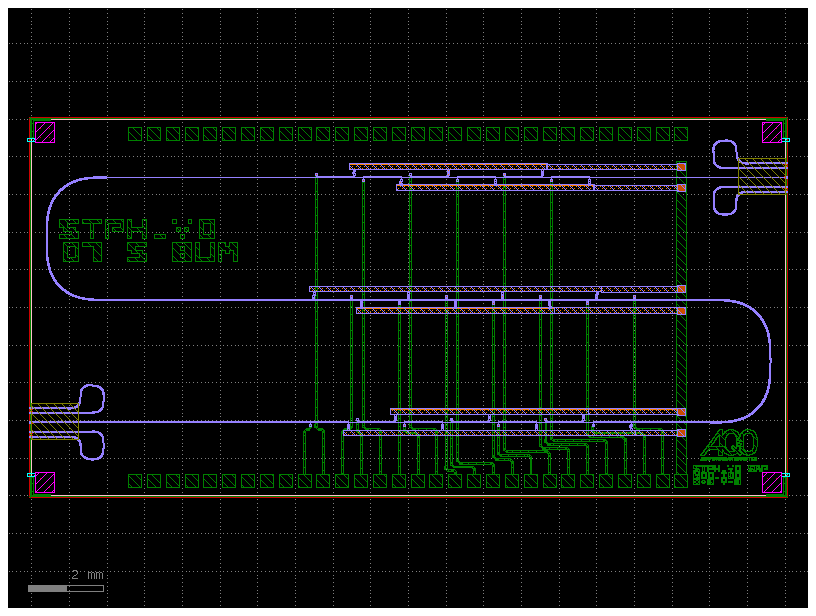

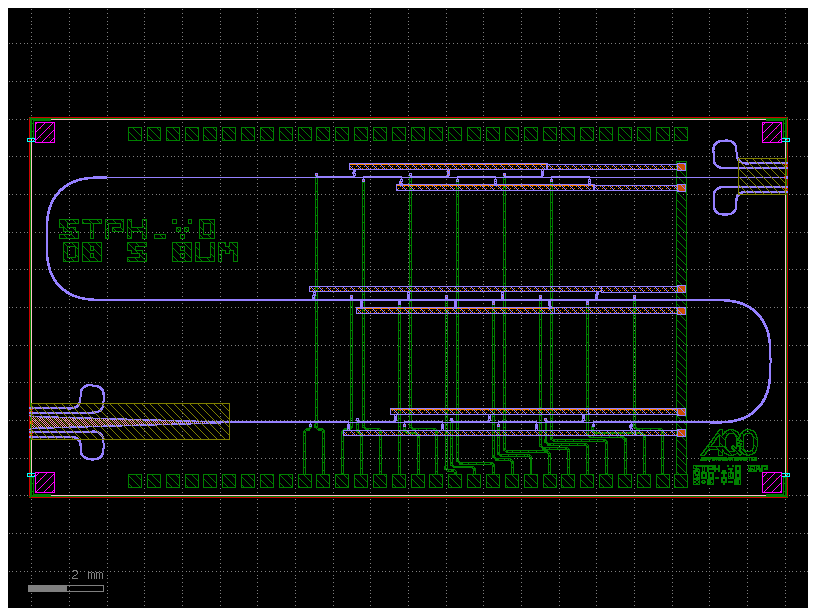

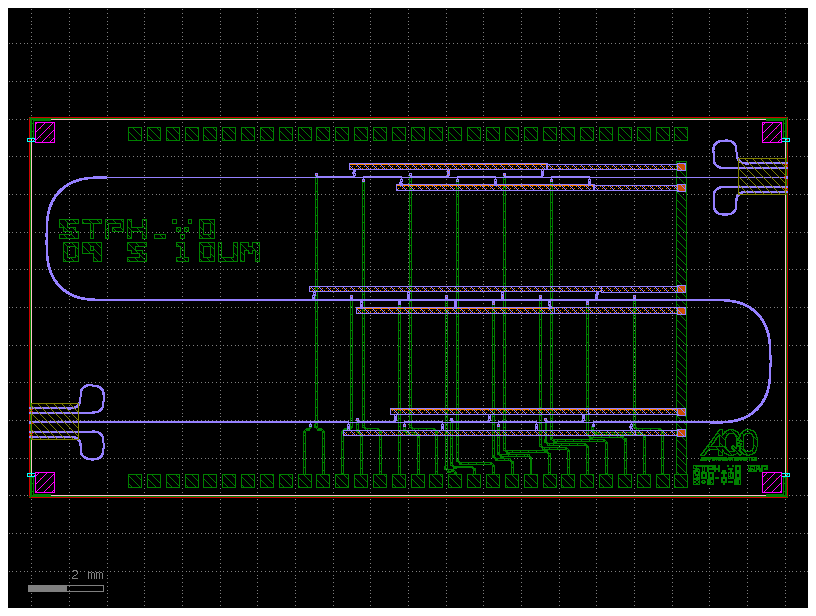

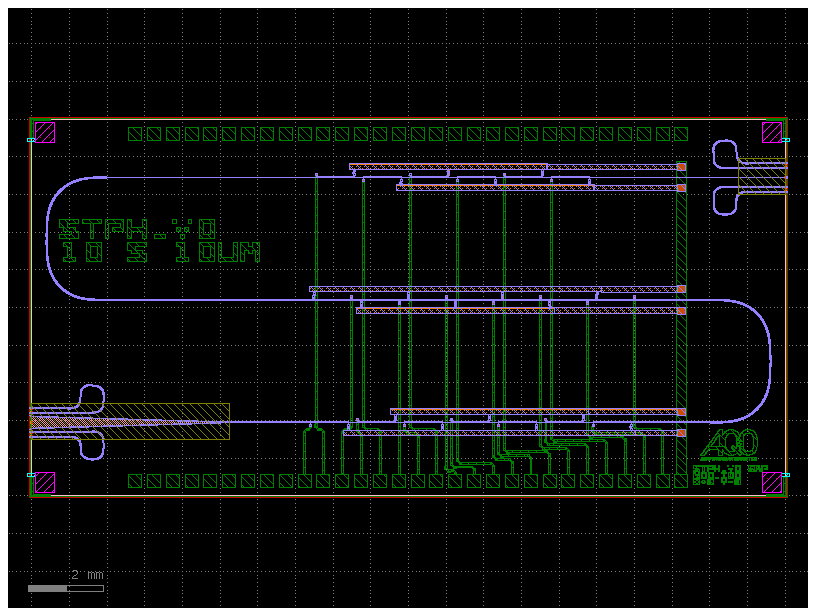

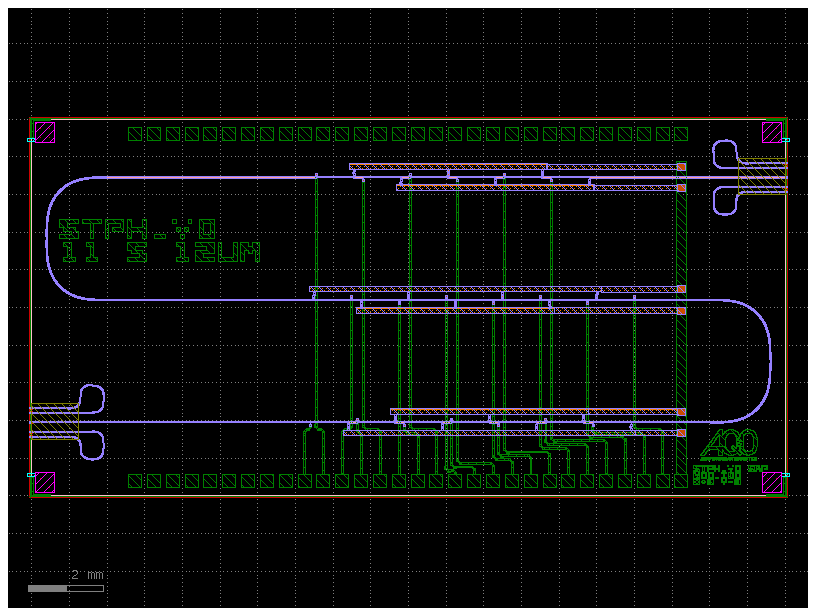

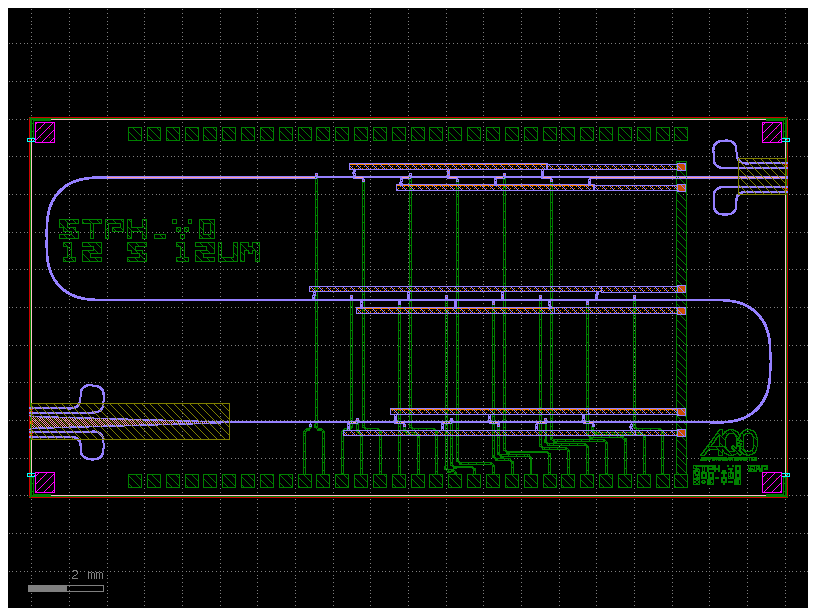

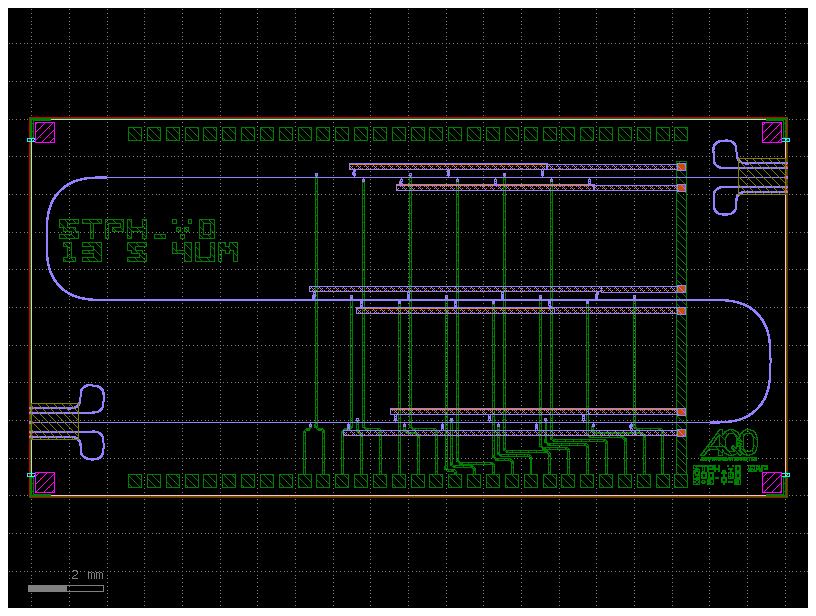

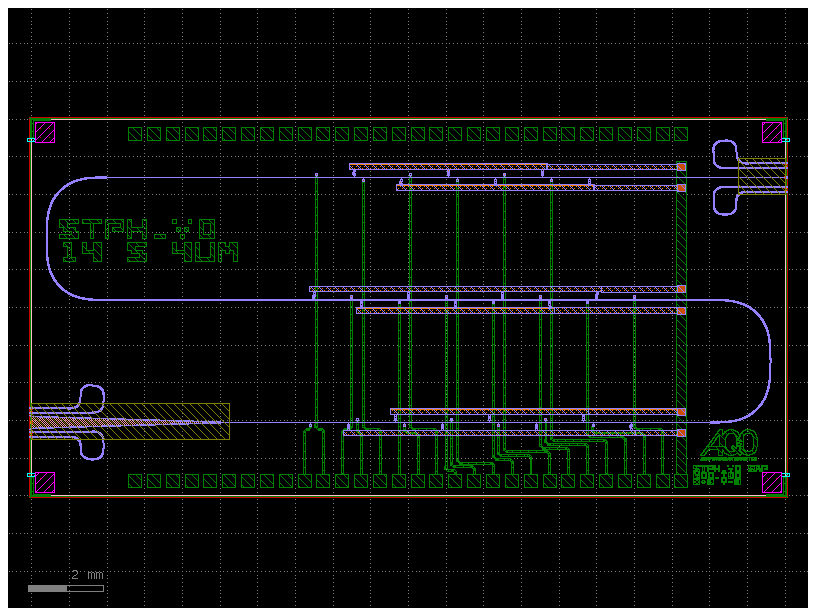

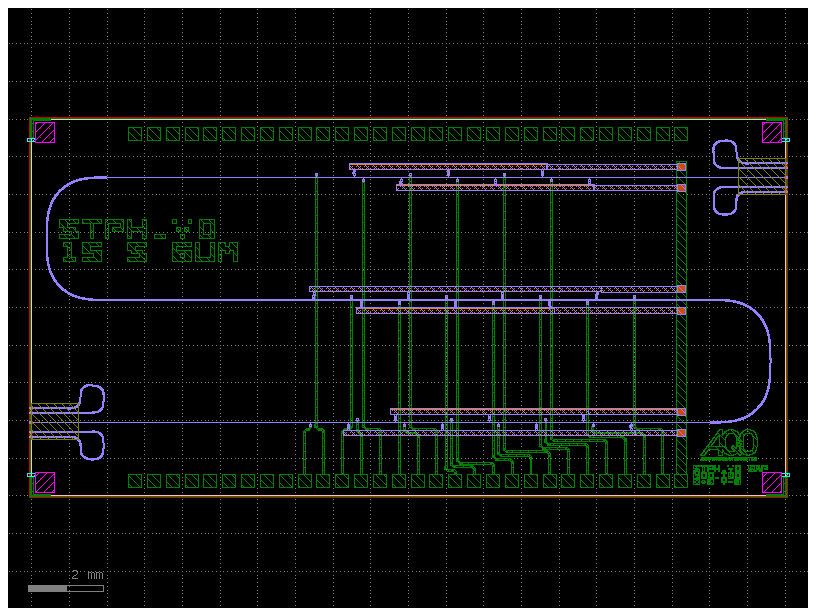

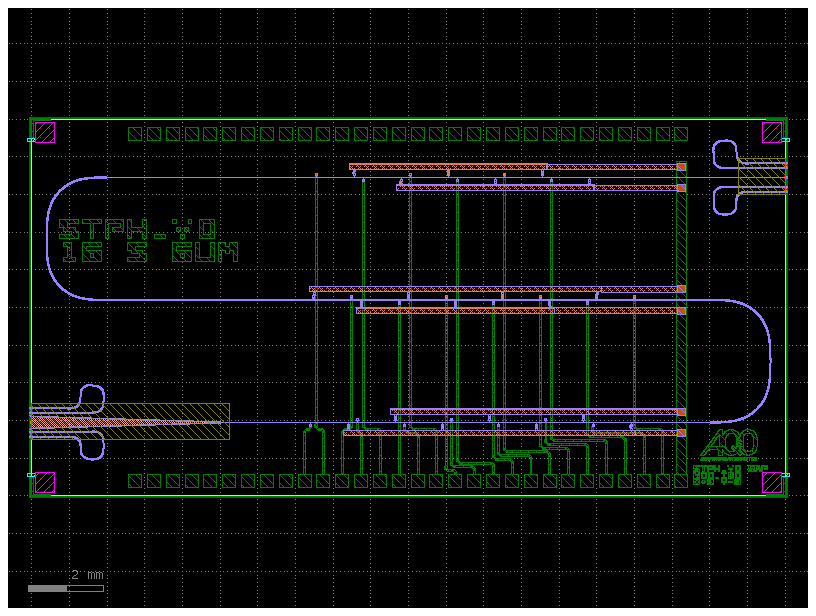

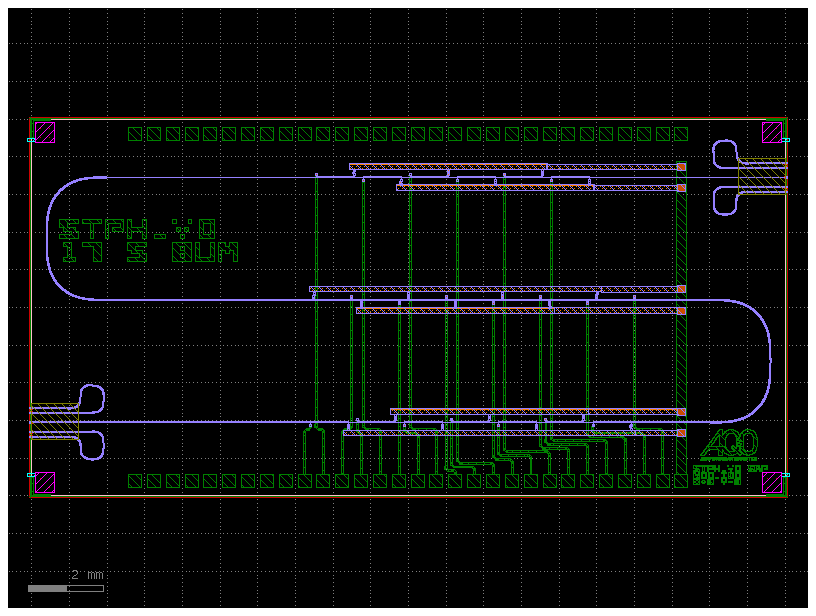

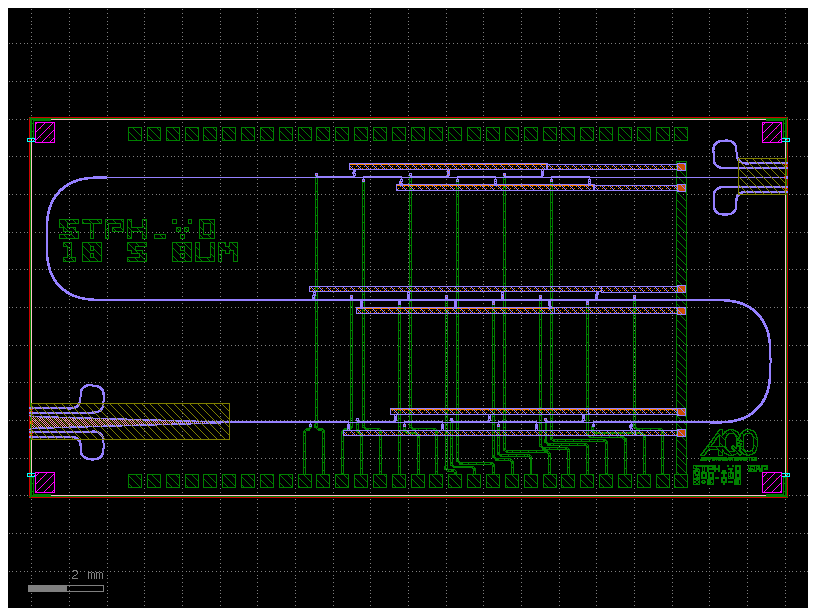

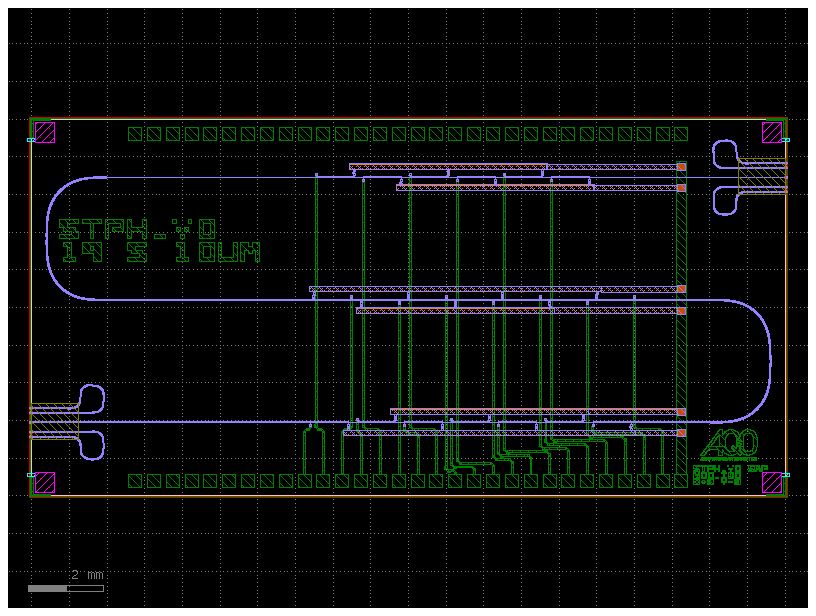

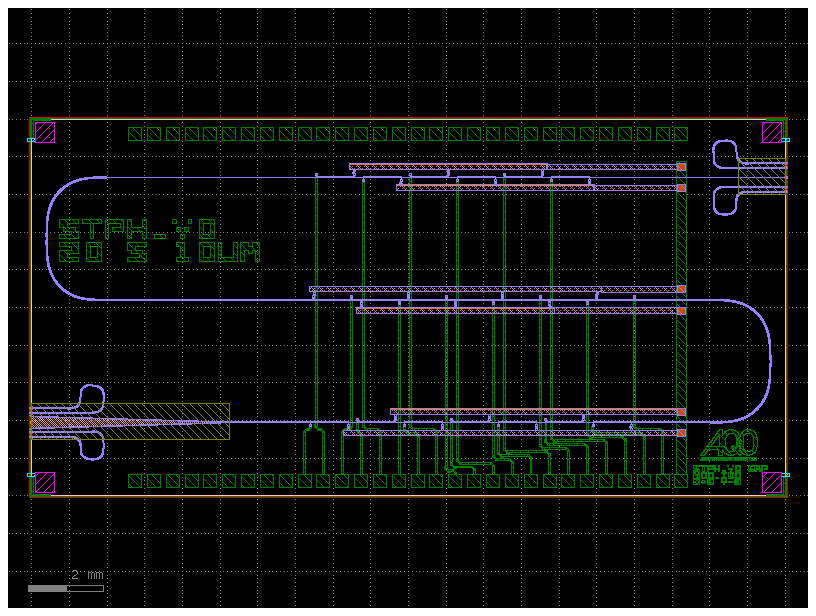

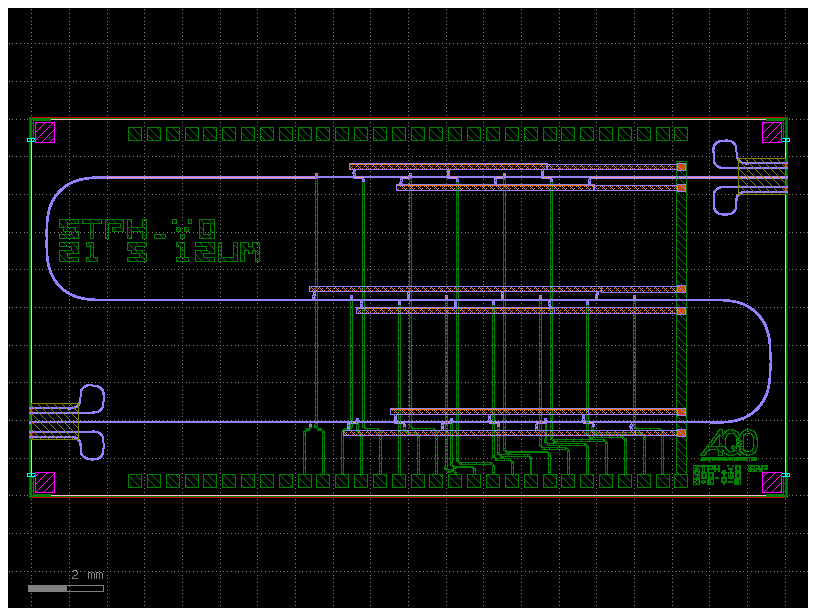

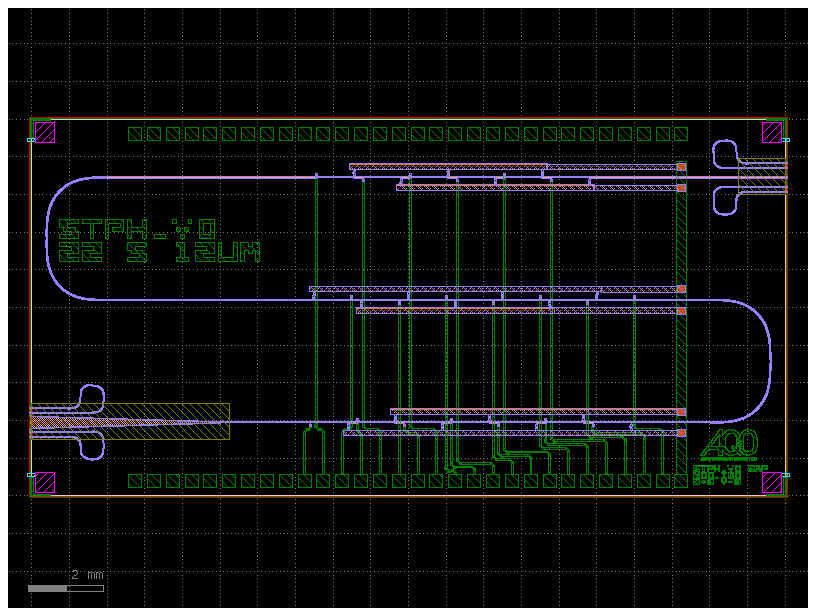

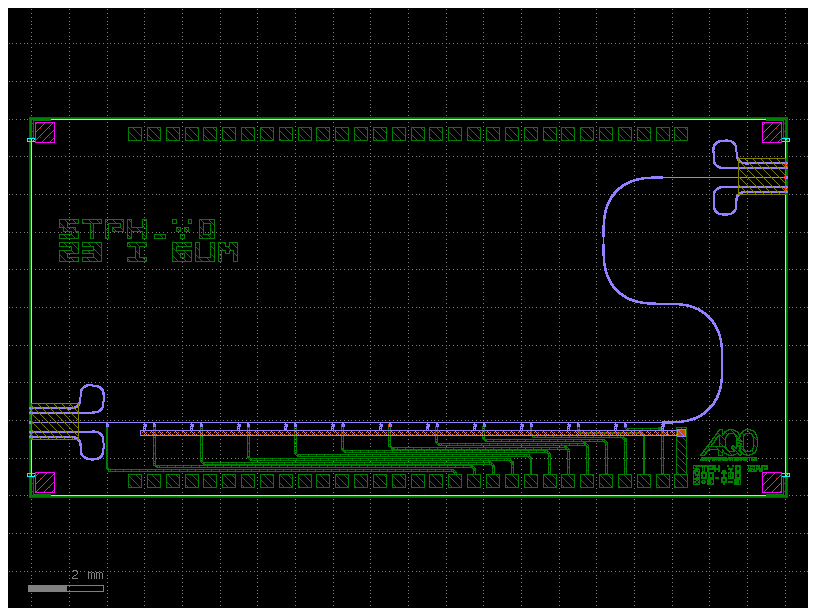

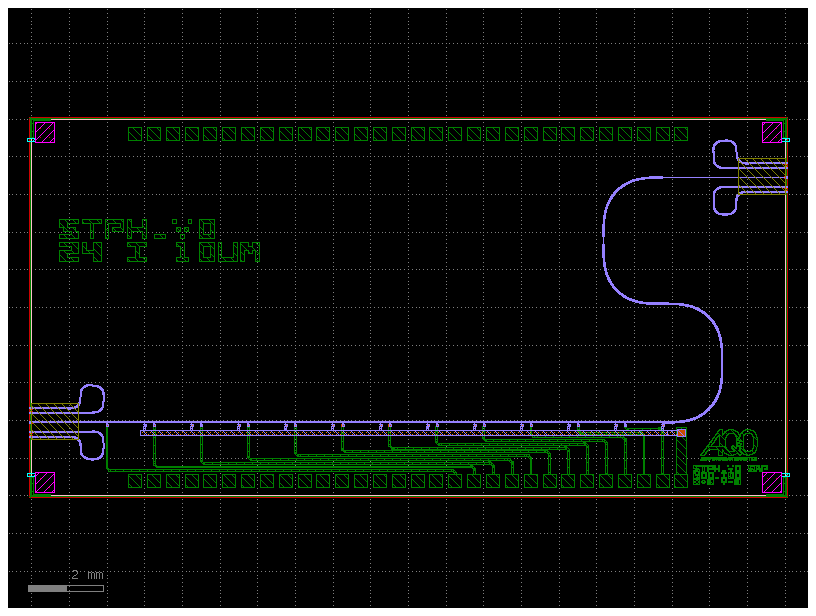

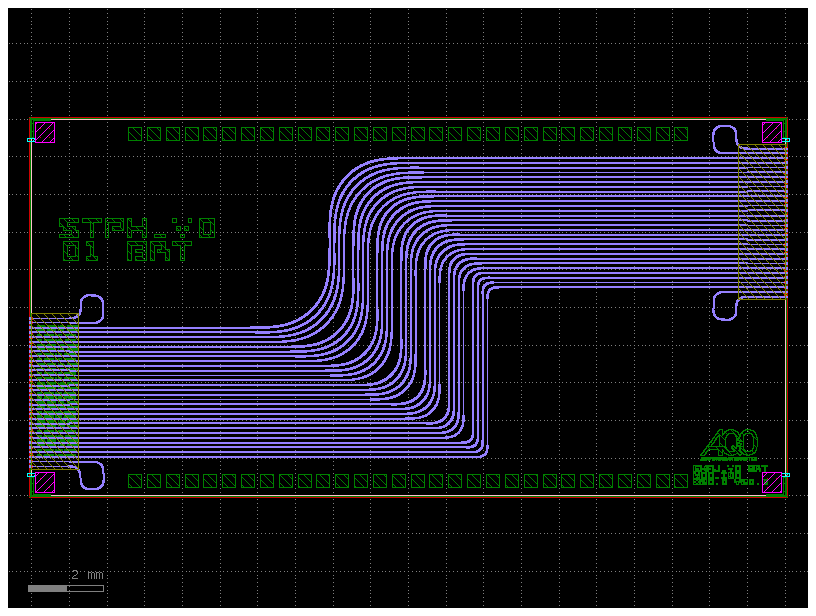

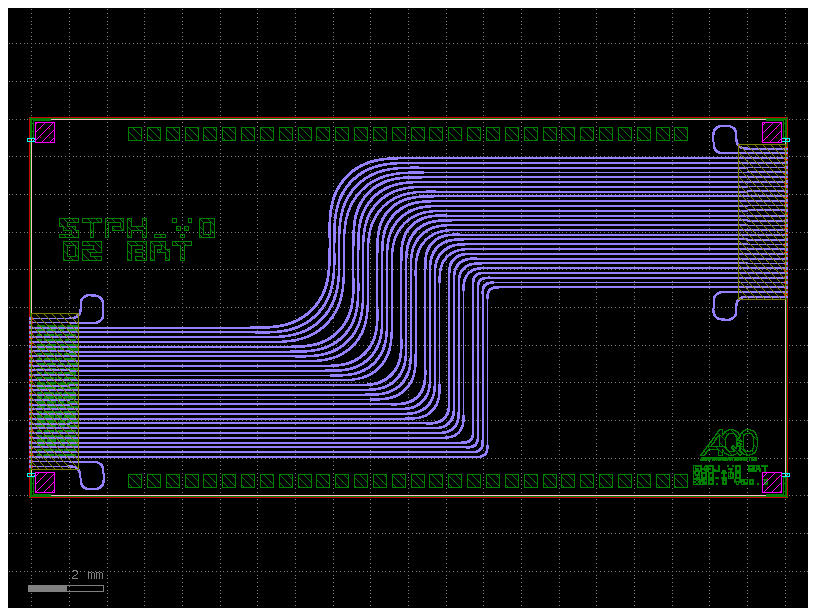

In [5]:
for die in STEPHAN_DIE_DEFS.keys():
    STEPHAN_DIE_DEFS[die]().plot()

In [6]:
assign_array[(0, -3)] =     STEPHAN_DIE_DEFS[1]
assign_array[(1, -3)] =     STEPHAN_DIE_DEFS[2]
assign_array[(0, -2)] =     STEPHAN_DIE_DEFS[3]
assign_array[(1, -2)] =     STEPHAN_DIE_DEFS[4]
assign_array[(-1, -1)] =    STEPHAN_DIE_DEFS[5]
assign_array[(0, -1)] =     STEPHAN_DIE_DEFS[6]
assign_array[(1, -1)] =     STEPHAN_DIE_DEFS[7]
assign_array[(2, -1)] =     STEPHAN_DIE_DEFS[8]
assign_array[(-1, 0)] =     STEPHAN_DIE_DEFS[9]
assign_array[(0, 0)] =      STEPHAN_DIE_DEFS[10]
assign_array[(1, 0)] =      STEPHAN_DIE_DEFS[11]
assign_array[(2, 0)] =      STEPHAN_DIE_DEFS[12]
assign_array[(-1, 1)] =     STEPHAN_DIE_DEFS[13]
assign_array[(0, 1)] =      STEPHAN_DIE_DEFS[14]
assign_array[(1, 1)] =      STEPHAN_DIE_DEFS[15]
assign_array[(2, 1)] =      STEPHAN_DIE_DEFS[16]
assign_array[(-1, 2)] =     STEPHAN_DIE_DEFS[17]
assign_array[(0, 2)] =      STEPHAN_DIE_DEFS[18]
assign_array[(1, 2)] =      STEPHAN_DIE_DEFS[19]
assign_array[(2, 2)] =      STEPHAN_DIE_DEFS[20]
assign_array[(0, 3)] =      STEPHAN_DIE_DEFS[21]
assign_array[(1, 3)] =      STEPHAN_DIE_DEFS[22]
assign_array[(0, 4)] =      STEPHAN_DIE_DEFS[23]
assign_array[(1, 4)] =      STEPHAN_DIE_DEFS[24]


for die in assign_array:
    if assign_array[die] !=None:
        die_name = ("{}_I{}_{}\nX{:.1f}\nY{:.1f}".format(WAFER_ID.split('_')[-1], die[0], die[1],
                                                         float(result.get_center(die)[0])/1000, 
                                                         float(result.get_center(die)[1])/1000))
        dieref = wafer_filled.add_ref(assign_array[die](chip_id_label = die_name,))
        dieref.dmove(origin=(0,0), destination=result.get_center(die))

In [7]:
"""
Adding wafer-level labels and logo.
Currently done manually, in future might be automated.
"""
wlabel_text = gf.partial(gf.components.text, layer="LABEL_SIN")
wafer_label = wlabel_text(size=1000, 
                          text = WAFER_ID, 
                          justify = 'center' )

t_label = wlabel_text(size=750, 
                      text = 'Si3N4: {:.0f}nm'.format(SIN_THICKNESS), 
                      justify = 'left' )

teos_label = wlabel_text(size=750, 
                         text = ' TEOS: {:.0f}nm'.format(TEOS_THICKNESS), 
                         justify = 'left' )

pecvd_label = wlabel_text(size=750, 
                          text = 'PECVD_OX: {:.0f}nm'.format(PECVD_OXIDE_THICKNESS),
                          justify = 'left' )

tio2_label = wlabel_text(size=750, 
                         text = 'TiO2: {:.0f}nm'.format(TIO2_THICKNESS), 
                         justify = 'left' )


label_block = flexgrid(components=(
                                        
                                        pecvd_label,
                                        tio2_label,
                                        teos_label,
                                        t_label,
                                        wafer_label
    ),
                                    spacing=(100,200),
                                    shape=(5,1),
                                    align_x='xmin',
                                    align_y='center'
                                    )

lb_ref = wafer_filled.add_ref(label_block, columns=2, rows=2, column_pitch=55000, row_pitch=-55000).dmove(origin=(0,0), destination=(-55000/2 - label_block.dxsize/2, 55000/2 - label_block.dysize/2))
lb_box_ref = wafer_filled.add_ref(gf.components.rectangle(size=(label_block.dxsize, label_block.dysize), layer='FLOORPLAN'), columns=2, rows=2, column_pitch=55000 , row_pitch=55000).dmove(origin=(0,0), destination=(lb_ref.dxmin, lb_ref.dymin))

In [8]:
""" 
GET a list of cells, which suppose to be processed by PEC in a loop 
and printing it to a file for later use in BEAMER
"""
dies_to_PEC = []

for inst in wafer_filled.insts:
    if "ekst_v2" in inst.cell_name:
        dies_to_PEC.append("True\t {}\n".format(inst.cell_name))
    else:
        dies_to_PEC.append("False\t {}\n".format(inst.cell_name))



""" Fill the wafer with a grid of tiles for better etch uniformity
"""

print(dies_to_PEC)

['False\t Unnamed_387\n', 'False\t Unnamed_396\n', 'True\t ekst_v2_brt_master_EKST_v2_BRT_MDFdie_frame_mesa_Mdies__bc780974\n', 'True\t ekst_v2_brt_master_EKST_v2_BRT_MDFdie_frame_mesa_Mdies__2ad91cde\n', 'False\t stephan_master_serpentine_EKST_v2_STEPHAN_MDFdie_frame__7309f14c\n', 'False\t stephan_master_serpentine_EKST_v2_STEPHAN_MDFdie_frame__da63dce0\n', 'False\t stephan_master_serpentine_EKST_v2_STEPHAN_MDFdie_frame__cc98dd6d\n', 'False\t stephan_master_serpentine_EKST_v2_STEPHAN_MDFdie_frame__cd2003fd\n', 'False\t stephan_master_serpentine_EKST_v2_STEPHAN_MDFdie_frame__041733a5\n', 'False\t stephan_master_serpentine_EKST_v2_STEPHAN_MDFdie_frame__bd4372fc\n', 'False\t stephan_master_serpentine_EKST_v2_STEPHAN_MDFdie_frame__3df3239e\n', 'False\t stephan_master_serpentine_EKST_v2_STEPHAN_MDFdie_frame__3d73692d\n', 'False\t stephan_master_serpentine_EKST_v2_STEPHAN_MDFdie_frame__1056d59d\n', 'False\t stephan_master_serpentine_EKST_v2_STEPHAN_MDFdie_frame__8576fe6b\n', 'False\t stepha

In [10]:
if ADD_TILES:
    if VERBOSE:
        print("Tiling started at {}".format(gf.get_layer_info("WAFER")))
    fc = gf.components.rectangle(size=(20,20), layer="TILES_SIN")
    fill_tiled(
    wafer_filled,
    fc,
    [(gf.get_layer_info("WAFER"), 0)],
    exclude_layers=[
        (gf.get_layer_info("KEEPOUT_WAFER"), 20),
        (gf.get_layer_info("WG"), 20),
        (gf.get_layer_info("M2"), 20),
        (gf.get_layer_info("SIN_ETCH"), 20),
        (gf.get_layer_info('LABEL_SIN'), 20),
        (gf.get_layer_info('M1'), 20),
        (gf.get_layer_info('KEEPOUT_DICING'), 20),
        (gf.get_layer_info('LABEL_M1'), 20),
        (gf.get_layer_info('KEEPOUT_MARKERS'), 20),
        
    ],
    x_space=20,
    y_space=20,
    multi=True, 
    )  

    if VERBOSE:
        print("Tiling finished")


Tiling started at WAFER (99/0)
Tiling finished


In [11]:
wafer_filled.show()

In [ ]:

if EXPORT_FILES:
    wafer_filled.show()
    wafer_filled.write('exports/{}.oas'.format(WAFER_ID))
    wafer_filled.write_gds('exports/{}.gds'.format(WAFER_ID))
    with open("exports/{}_cell_list.txt".format(WAFER_ID), "w") as output:
        output.write("enabled\t%VarName%\n")
        output.writelines(dies_to_PEC)